In [1]:
1+1


2

In [2]:
import seaborn as sns
df = sns.load_dataset('iris')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
# 독립변수 : petal_length , 종속변수 : sepal_length 회귀분석 시행

#1. 선형성 확인
# 절대값 크기가 0.7이상 -> 강한 상관관계가 있다. / 0.2 ~ 0.4 이하면 약한 상관관계 / 0.2 이하 상관관계가 없다

df[['petal_length','sepal_length']].corr()

,petal_length,sepal_length
petal_length,1.000000,0.871754
sepal_length,0.871754,1.000000


In [5]:
X=df['petal_length']
y=df['sepal_length']

In [6]:
from statsmodels.formula.api import ols
lr = ols('sepal_length ~ petal_length', data = df).fit()


In [7]:
# 회귀계수
lr.params

,0
Intercept,4.306603
petal_length,0.408922


In [8]:
# 예측
y_pred = lr.predict(X)
y_pred

,0
0,4.879095
1,4.879095
2,4.838202
3,4.919987
4,4.879095
...,...
145,6.432999
146,6.351215
147,6.432999
148,6.514784


In [9]:
# 평가(mse, rmse)
# 숫자가 작을수록 좋음

res = y - y_pred
mse = (res**2).sum() / len(y)

import numpy as np
rmse = np.sqrt(mse)

rmse

np.float64(0.4043516107369241)

In [10]:
 lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           sepal_length   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     468.6
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           1.04e-47
Time:                        06:03:33   Log-Likelihood:                -77.020
No. Observations:                 150   AIC:                             158.0
Df Residuals:                     148   BIC:                             164.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        4.3066      0.078     54.939      0.000       4.152       4.462
petal_length     0.4089      0.019     21.646      0.000       0.372       0.446
==============================================================================
Omnibus:                        0.207   Durbin-Watson:                   1.867
Prob(Omnibus):                  0.902   Jarque-Bera (JB):                0.346
Skew:                           0.069   Prob(JB):                        0.841
Kurtosis:                       2.809   Cond. No.                         10.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
# sepal_length = 4.3066 + petal_length * 0.4089

In [12]:
# sepal_length를 종속변수, sepal_width, petal_length, petal_width를 종속변수로 하는 다중 회귀분석을 시행

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [13]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.ols(formula = 'sepal_length ~ sepal_width + petal_length + petal_width', data = df )
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           sepal_length   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     295.5
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           8.59e-62
Time:                        06:03:38   Log-Likelihood:                -37.321
No. Observations:                 150   AIC:                             82.64
Df Residuals:                     146   BIC:                             94.69
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.8560      0.251      7.401      0.000       1.360       2.352
sepal_width      0.6508      0.067      9.765      0.000       0.519       0.783
petal_length     0.7091      0.057     12.502      0.000       0.597       0.821
petal_width     -0.5565      0.128     -4.363      0.000      -0.809      -0.304
==============================================================================
Omnibus:                        0.345   Durbin-Watson:                   2.060
Prob(Omnibus):                  0.842   Jarque-Bera (JB):                0.504
Skew:                           0.007   Prob(JB):                        0.777
Kurtosis:                       2.716   Cond. No.                         54.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

,sepal_length,petal_length,sepal_width,petal_width
sepal_length,1.000000,0.871754,-0.117570,0.817941
petal_length,0.871754,1.000000,-0.428440,0.962865
sepal_width,-0.117570,-0.428440,1.000000,-0.366126
petal_width,0.817941,0.962865,-0.366126,1.000000


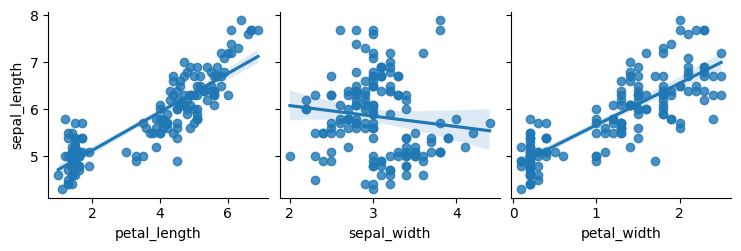

In [14]:
# 1) 독립변수와 종속변수 간 선형성 체크

import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df, x_vars = ['petal_length','sepal_width', 'petal_width'], y_vars = ['sepal_length'], kind = 'reg')

df[['sepal_length', 'petal_length' , 'sepal_width', 'petal_width']].corr()

In [15]:
# 잔차의 독립성 검정
# 더빈-왓슨 통계량

from statsmodels.stats.stattools import durbin_watson
resid = result.resid
dw = durbin_watson(resid)
print(dw)

2.0603819512523915


In [16]:
# 정규성 검사 -> shapiro
from scipy.stats import shapiro
_, p_value = shapiro(resid)
print(p_value)

0.9349086404927768


In [17]:
# 등분산 검사

from scipy.stats import bartlett

stat, p_value = bartlett(df['sepal_length'], resid)
print(p_value)

8.7887196317943e-29


In [18]:
# 다중 공산성 검사
# 독립변수 간의 강한 상관관계
# 10 이하로 나와야
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

select_df = df[['sepal_width','petal_width','petal_length']]

vif = pd.DataFrame()
vif['VIF Factor'] = [variance_inflation_factor(select_df.values, i) for i in range(select_df.shape[1])]
vif['features'] = select_df.columns
vif

,VIF Factor,features
0,5.856965,sepal_width
1,43.292574,petal_width
2,62.071308,petal_length


In [19]:
select_df = df[['sepal_width','petal_width']]

vif = pd.DataFrame()
vif['VIF Factor'] = [variance_inflation_factor(select_df.values, i) for i in range(select_df.shape[1])]
vif['features'] = select_df.columns
vif

,VIF Factor,features
0,2.891774,sepal_width
1,2.891774,petal_width


In [20]:
import seaborn as sns
df = sns.load_dataset('iris')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [29]:
x = df[['sepal_width','petal_length', 'petal_width']]
y = df[['sepal_length']]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=10)

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [30]:
# 회귀 계수 기울기
lr.coef_

array([[ 0.71327018,  0.75876017, -0.67284346]])

In [31]:
# 절편값
print(lr.intercept_)

[1.61230851]


In [32]:
# r_square

r_square = lr.score(X_train, y_train)
r_square

0.853198853058563

In [33]:
y_pred = lr.predict(X_test)
y_pred

array([[5.71667817],
       [6.28116432],
       [5.25497973],
       [6.30043498],
       [4.89379565],
       [5.021666  ],
       [6.1041436 ],
       [5.97621123],
       [5.04099868],
       [6.14918927],
       [6.15727462],
       [6.12941228],
       [5.4131741 ],
       [4.67981459],
       [5.25902241],
       [6.51232871],
       [6.37529834],
       [4.60393858],
       [5.12041104],
       [4.67071659],
       [6.81583278],
       [6.37826635],
       [6.0403956 ],
       [5.34450275],
       [5.92964657],
       [4.74659261],
       [6.1314996 ],
       [5.99794357],
       [6.30953298],
       [7.92617271],
       [6.29639231],
       [6.06876426],
       [7.07637849],
       [5.86431757],
       [5.91088223],
       [4.82246863],
       [6.8780618 ],
       [6.67216609],
       [7.15471618],
       [6.14558297],
       [4.98230601],
       [4.91906433],
       [5.55532181],
       [4.0373651 ],
       [6.45572336]])

In [36]:
# 잔차
res = y_test - y_pred

# 모델평가 (mse, rmse)
mse = (res**2).sum() / len(y)
print(mse)
import numpy as py
rmse = np.sqrt(mse)
print(rmse)

sepal_length    0.029065
dtype: float64
sepal_length    0.170484
dtype: float64


In [41]:
# 과적합 방지, 변수선택, 차원 축소
# 릿지 L2 정규화 -> 회귀 계수의 제곱의 합에 패널티(alpha)를 적용
# 라쏘 L1 정규화 -> 회귀 계수의 절대값의 합에 패널티(alpha)를 적용
# 엘라스틱 넷 : L1과 L2 정규화 두 개 조합 -> 릿지와 라쏘의 장점을 결합하여, L1 패널티(alpha)로 변수 선택과 L2 패널티로 계수 축소를 동시에 수행

# 패널티(alpha)가 크면 패널티를 강하게 적용하기 때문에 과적합을 막을 수 있지만
# 너무 커지면 과소적합의 가능성이 존재. 따라서 최적의 알파를 찾아야함 -> "그리드 서치 알고리즘"

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
# 릿지
ridge = Ridge()
parameter = {'alpha': (0.01, 0.2 , 0.7, 1.5)}
ridge_regressor = GridSearchCV(ridge, parameter, scoring ='r2')
ridge_regressor.fit(X_train, y_train)

# 최적파라미터 출력 및 성능

print(f"Best parameter Ridge : {ridge_regressor.best_params_}")
print(f"Best score Ridge : {ridge_regressor.best_score_}")

Best parameter Ridge : {'alpha': 0.01}
Best score Ridge : 0.8286498244963101


In [43]:
# 라쏘
lasso = Lasso()
lasso_regressor = GridSearchCV(lasso, parameter, scoring = 'r2')
lasso_regressor.fit(X_train, y_train)

# 최적파라미터 출력 및 성능

print(f"Best parameter Lasso : {lasso_regressor.best_params_}")
print(f"Best score Lasso : {lasso_regressor.best_score_}")

Best parameter Lasso : {'alpha': 0.01}
Best score Lasso : 0.814156502671422


In [48]:
# 엘라스틱넷
elasticnet = ElasticNet()

parameter = {
    'alpha' : [0.01,0.1,0.5]
    ,'l1_ratio' : [0.1, 0.5, 0.7,1]
}
elastic_net_regressor = GridSearchCV(elasticnet,parameter, scoring ='r2')
elastic_net_regressor.fit(X_train, y_train)

# 최적파라미터 출력 및 성능

print(f"Best parameter ElasticNet : {elastic_net_regressor.best_params_}")
print(f"Best score ElasticNet : {elastic_net_regressor.best_score_}")

Best parameter ElasticNet : {'alpha': 0.01, 'l1_ratio': 0.1}
Best score ElasticNet : 0.8249909595067267
